In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

import pandas as pd
import json

In [18]:
# JSON 파일 로딩
with open("data/News_Category_Dataset_v3.json", "r", encoding="utf-8") as f:
    data = [json.loads(line) for line in f]

In [19]:
# 데이터프레임 생성
df = pd.DataFrame(data)
df.columns

Index(['link', 'headline', 'category', 'short_description', 'authors', 'date'], dtype='object')

In [20]:
# 텍스트와 라벨 준비
df["text"] = df["headline"] + " " + df["short_description"]
X = df["text"]
y = df["category"]

X.shape, y.shape

((209527,), (209527,))

In [21]:
# 라벨 수 줄이기
top_categories = y.value_counts().nlargest(5).index
df = df[df["category"].isin(top_categories)]
X = df["text"]
y = df["category"]

X.shape, y.shape

((90623,), (90623,))

In [22]:
df["category"].value_counts()

category
POLITICS          35602
WELLNESS          17945
ENTERTAINMENT     17362
TRAVEL             9900
STYLE & BEAUTY     9814
Name: count, dtype: int64

In [99]:
# 예시: 원문 텍스트를 따로 저장
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df["text"], df["category"], test_size=0.2, random_state=42
)

40:20:20:10:10 정도로, 심각한 불균형은 아니지만 학습을 위해 class_weight="balanced" 진행

In [23]:
# 벡터화 (TF-IDF)
vectorizer = TfidfVectorizer(stop_words="english", max_features=5000)
X_vec = vectorizer.fit_transform(X)

In [24]:
# 학습/테스트셋 분할
X_train, X_test, y_train, y_test = train_test_split(X_vec, y, test_size=0.2, random_state=42)

In [27]:
# 로지스틱 회귀 모델 학습
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [28]:
# 평가
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8978758620689655
                precision    recall  f1-score   support

 ENTERTAINMENT       0.87      0.85      0.86      3488
      POLITICS       0.92      0.95      0.94      7138
STYLE & BEAUTY       0.92      0.84      0.88      1956
        TRAVEL       0.87      0.83      0.85      1968
      WELLNESS       0.88      0.91      0.89      3575

      accuracy                           0.90     18125
     macro avg       0.89      0.88      0.88     18125
  weighted avg       0.90      0.90      0.90     18125



In [ ]:
# 로지스틱 회귀 모델 학습 - balanced 추가
model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train, y_train)

# 평가
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8940137931034483
                precision    recall  f1-score   support

 ENTERTAINMENT       0.85      0.86      0.86      3488
      POLITICS       0.96      0.91      0.93      7138
STYLE & BEAUTY       0.88      0.88      0.88      1956
        TRAVEL       0.81      0.88      0.84      1968
      WELLNESS       0.88      0.91      0.89      3575

      accuracy                           0.89     18125
     macro avg       0.87      0.89      0.88     18125
  weighted avg       0.90      0.89      0.89     18125



# balanced 사용 핵심 차이점
- 소수 클래스의 recall을 개선
- 실전에서는 정확도보다 recall이 더 중요할 수 있음

하지만 정확도가 떨어진건 찜찜해서 weights를 조절해 보기로 함.

In [ ]:
# 로지스틱 회귀 모델 학습 - 가중치 수동 조절
weights = {
    "POLITICS": 0.7,
    "WELLNESS": 0.8,
    "ENTERTAINMENT": 1.2,
    "TRAVEL": 1.7,
    "STYLE & BEAUTY": 1.7
}

model = LogisticRegression(max_iter=1000, class_weight=weights)
model.fit(X_train, y_train)

# 평가
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.898151724137931
                precision    recall  f1-score   support

 ENTERTAINMENT       0.85      0.87      0.86      3488
      POLITICS       0.94      0.93      0.94      7138
STYLE & BEAUTY       0.88      0.87      0.87      1956
        TRAVEL       0.82      0.88      0.85      1968
      WELLNESS       0.91      0.89      0.90      3575

      accuracy                           0.90     18125
     macro avg       0.88      0.89      0.88     18125
  weighted avg       0.90      0.90      0.90     18125



# 가중치 수동 조절
- 정확도 소폭 상승
- 각 클래스에 대해 균형 잡힌 민감도 확보

In [ ]:
# Grid Search로 class_weight 튜닝
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from itertools import product

import numpy as np

classes = ["POLITICS", "WELLNESS", "ENTERTAINMENT", "TRAVEL", "STYLE & BEAUTY"]

# 가중치 후보
weight_values = [0.7, 1.0, 1.3]

weight_combinations = []
for combo in product(weight_values, repeat=len(classes)):
    weight_combinations.append(dict(zip(classes, combo)))

param_grid = {
    "class_weight": weight_combinations
}

model = LogisticRegression(max_iter=50)

grid = RandomizedSearchCV(
    model,
    param_distributions={"class_weight": weight_combinations},
    n_iter=50,
    cv=3,
    scoring="f1_macro",
    verbose=1,
    n_jobs=-1,
    random_state=42
)
grid.fit(X_train, y_train)

print("Best score:", grid.best_score_)
print("Best weights:", grid.best_params_["class_weight"])

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best score: 0.8796740461514032
Best weights: {'POLITICS': 1.0, 'WELLNESS': 1.3, 'ENTERTAINMENT': 1.0, 'TRAVEL': 1.3, 'STYLE & BEAUTY': 1.3}


c:\ProgramData\anaconda3\envs\np1.26\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 50 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=50).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [101]:
# 로지스틱 회귀 모델 학습 - 최적화 가중치 적용
best_weights = {
    "POLITICS": 1.0,
    "WELLNESS": 1.3,
    "ENTERTAINMENT": 1.0,
    "TRAVEL": 1.3,
    "STYLE & BEAUTY": 1.3
}

model = LogisticRegression(max_iter=1000, class_weight=best_weights)
model.fit(X_train, y_train)

# 평가
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8987586206896552
                precision    recall  f1-score   support

 ENTERTAINMENT       0.88      0.84      0.86      3488
      POLITICS       0.93      0.95      0.94      7138
STYLE & BEAUTY       0.90      0.85      0.87      1956
        TRAVEL       0.86      0.85      0.85      1968
      WELLNESS       0.87      0.92      0.89      3575

      accuracy                           0.90     18125
     macro avg       0.89      0.88      0.88     18125
  weighted avg       0.90      0.90      0.90     18125



# 더 정밀한 최적화 가중치 조절
- 지금까지 중 최고 정확도 확보
- 절묘한 균형 유지

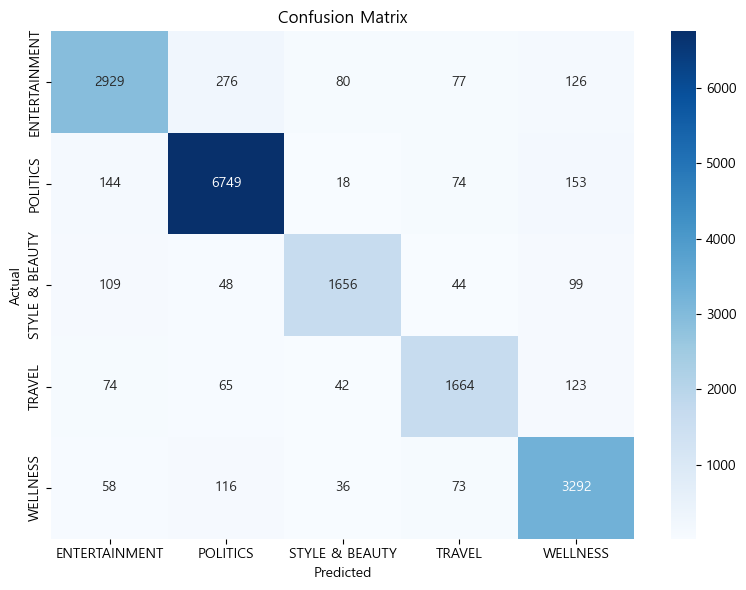

In [97]:
# 혼동 행렬 시각화 코드
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 예측값과 실제값
y_pred = model.predict(X_test)

# 혼동 행렬 계산
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

# 시각화
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_,
            yticklabels=model.classes_)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [ ]:
# 예측값
y_pred = model.predict(X_test)

# 틀린 예측 인덱스
wrong_idx = (y_pred != y_test)

# 틀린 샘플 추출
wrong_samples = pd.DataFrame({
    "text": X_test_text[wrong_idx],
    "actual": y_test[wrong_idx],
    "predicted": y_pred[wrong_idx]
})

print(wrong_samples.sample(5))


                                                     text    actual  \
186092  The Top 10 Workout Songs For October This mont...  WELLNESS   
149096  3 Ways to Get Outside for Fall The autumn leav...    TRAVEL   
80152   The FDA's Blood Donor Policy Is Still Homophob...  POLITICS   
204842  Playing Pick-Up Soccer Games Around The World ...    TRAVEL   
127413  What We Can Learn From Lawrence of Arabia Not ...  POLITICS   

            predicted  
186092  ENTERTAINMENT  
149096       WELLNESS  
80152        WELLNESS  
204842       WELLNESS  
127413         TRAVEL  


1. POLITICS → WELLNESS
   - 정치적 맥락인데 "교훈", "성찰", "회복" 같은 단어가 들어가면 웰빙으로 오해 가능
2. ENTERTAINMENT → POLITICS
   - 유명 배우가 정치적 발언을 한 기사 → 연예 vs 정치 경계가 모호
3. WELLNESS → TRAVEL
   - 여행과 웰빙이 섞인 주제 → 모델이 "여행" 키워드에 더 반응
4. POLITICS → WELLNESS
   - 교육 정책은 정치적이지만, "사회적 복지"로 인식되면 웰빙으로 오해 가능
5. TRAVEL → POLITICS
   - 여행 콘텐츠지만 "대통령", "주", "역사" 키워드가 정치적 느낌을 줌

In [ ]:
# TF-IDF 조정 하이퍼 튜닝
vectorizer = TfidfVectorizer(
    stop_words=[
        # 정치 편향 단어
        "president", "predicts"],
    max_df=0.8,
    min_df=5,
    sublinear_tf=True,
    ngram_range=(1, 2)
)
X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

model = LogisticRegression(class_weight=best_weights, max_iter=500)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9122758620689655
                precision    recall  f1-score   support

 ENTERTAINMENT       0.91      0.87      0.89      3488
      POLITICS       0.93      0.95      0.94      7138
STYLE & BEAUTY       0.94      0.85      0.89      1956
        TRAVEL       0.89      0.86      0.87      1968
      WELLNESS       0.87      0.94      0.91      3575

      accuracy                           0.91     18125
     macro avg       0.91      0.89      0.90     18125
  weighted avg       0.91      0.91      0.91     18125



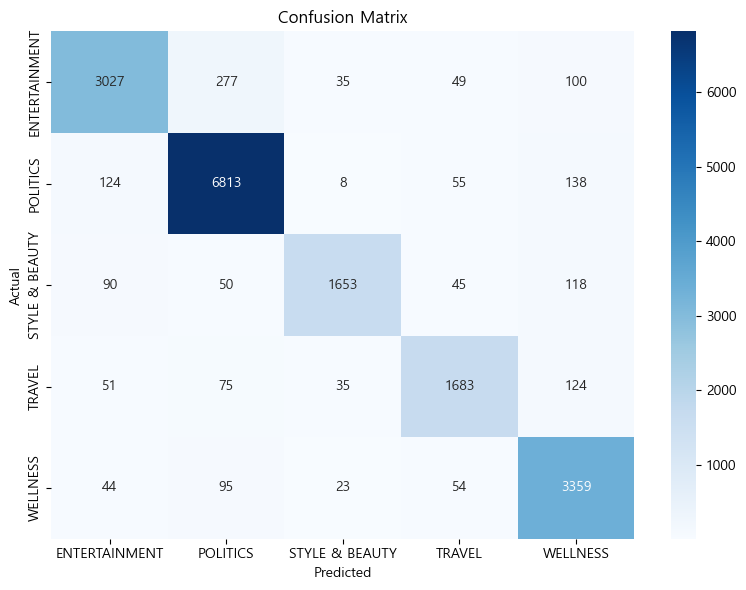

In [193]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [194]:
# 학습된 벡터라이저와 모델 저장
import joblib

joblib.dump(vectorizer, "tfidf_vectorizer.pkl")
joblib.dump(model, "text_classifier.pkl")

['text_classifier.pkl']